In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import RegularPolygon
from matplotlib.collections import PatchCollection
import stim

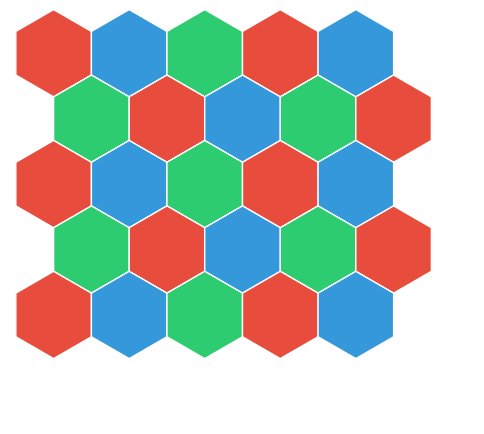

[[ 6.12323400e-17  1.00000000e+00]
 [-8.66025404e-01  5.00000000e-01]
 [-8.66025404e-01 -5.00000000e-01]
 [-1.83697020e-16 -1.00000000e+00]
 [ 8.66025404e-01 -5.00000000e-01]
 [ 8.66025404e-01  5.00000000e-01]
 [ 6.12323400e-17  1.00000000e+00]]
[[ 1.73205081  1.        ]
 [ 0.8660254   0.5       ]
 [ 0.8660254  -0.5       ]
 [ 1.73205081 -1.        ]
 [ 2.59807621 -0.5       ]
 [ 2.59807621  0.5       ]
 [ 1.73205081  1.        ]]
[[ 3.46410162  1.        ]
 [ 2.59807621  0.5       ]
 [ 2.59807621 -0.5       ]
 [ 3.46410162 -1.        ]
 [ 4.33012702 -0.5       ]
 [ 4.33012702  0.5       ]
 [ 3.46410162  1.        ]]
[[ 5.19615242  1.        ]
 [ 4.33012702  0.5       ]
 [ 4.33012702 -0.5       ]
 [ 5.19615242 -1.        ]
 [ 6.06217783 -0.5       ]
 [ 6.06217783  0.5       ]
 [ 5.19615242  1.        ]]
[[ 6.92820323  1.        ]
 [ 6.06217783  0.5       ]
 [ 6.06217783 -0.5       ]
 [ 6.92820323 -1.        ]
 [ 7.79422863 -0.5       ]
 [ 7.79422863  0.5       ]
 [ 6.92820323  1.     

In [2]:
def hex_grid(rows, cols, size=1):
    dx = size * np.sqrt(3)   
    dy = size * 1.5 
    coords = []
    for row in range(rows):
        y = row * dy
        offset = dx / 2 if row % 2 else 0  
        for col in range(cols):
            x = col * dx + offset
            coords.append((row, col, x, y))
    return coords

def color_for(row, col):
    # 3-coloring: guaranteed to differ from all 6 neighbors
    return (col - row - row // 2) % 3

size = 1
rows, cols = 5, 5
grid = hex_grid(rows, cols, size)

palette = ['#e74c3c', '#3498db', '#2ecc71']
patches, facecolors = [], []

for row, col, x, y in grid:
    patches.append(RegularPolygon((x, y), numVertices=6, radius=size, orientation=0))
    facecolors.append(palette[color_for(row, col)])

fig, ax = plt.subplots(figsize=(6, 7))
ax.add_collection(PatchCollection(patches, facecolor=facecolors, edgecolor='white', linewidth=1))
ax.set_xlim(-1, cols * size * np.sqrt(3) + 1)
ax.set_ylim(-1, rows * size * 1.5 + 1)
ax.set_aspect('equal')
ax.invert_yaxis()
ax.axis('off')
plt.show()

for patch in patches:
    verts = patch.get_verts()  # NOTE first vertex repeated at the end
    print(verts)

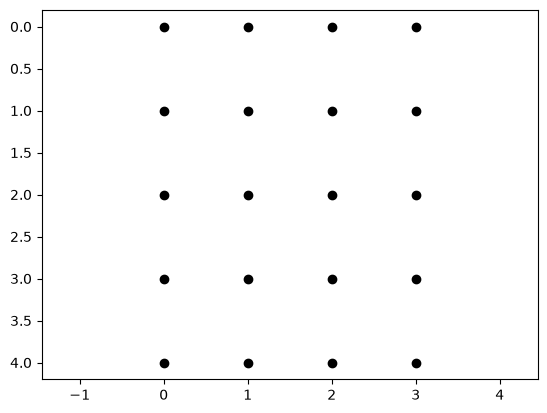

In [3]:
nx = 4
ny = 5
coords = np.array([x + 1j*y for y in range(ny) for x in range(nx)])

plt.scatter(coords.real, coords.imag, c='black')
plt.axis('equal') 
plt.gca().yaxis.set_inverted(True)
plt.show()

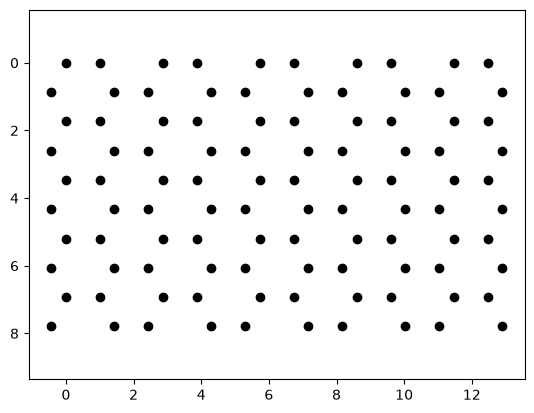

[ 0.        +0.j          1.        +0.j          2.8660254 +0.j
  3.8660254 +0.j          5.73205081+0.j          6.73205081+0.j
  8.59807621+0.j          9.59807621+0.j         11.46410162+0.j
 12.46410162+0.j         -0.4330127 +0.8660254j   1.4330127 +0.8660254j
  2.4330127 +0.8660254j   4.29903811+0.8660254j   5.29903811+0.8660254j
  7.16506351+0.8660254j   8.16506351+0.8660254j  10.03108891+0.8660254j
 11.03108891+0.8660254j  12.89711432+0.8660254j   0.        +1.73205081j
  1.        +1.73205081j  2.8660254 +1.73205081j  3.8660254 +1.73205081j
  5.73205081+1.73205081j  6.73205081+1.73205081j  8.59807621+1.73205081j
  9.59807621+1.73205081j 11.46410162+1.73205081j 12.46410162+1.73205081j
 -0.4330127 +2.59807621j  1.4330127 +2.59807621j  2.4330127 +2.59807621j
  4.29903811+2.59807621j  5.29903811+2.59807621j  7.16506351+2.59807621j
  8.16506351+2.59807621j 10.03108891+2.59807621j 11.03108891+2.59807621j
 12.89711432+2.59807621j  0.        +3.46410162j  1.        +3.46410162j
  2.8

In [4]:
def square_to_hex(coords, scale=1):
    """
    given list of coordinates (complex numbers) convert them to points of a regular hexagonal grid.
    We are assuming that (0,0) is the top left vertex of the top left hexagon.
    """
    
    hex_coords = []
    a = np.sqrt(3)/4

    for z in coords.copy():
        if z.imag%2 == 0: # top and bottom of hexagons
            z += (2*a) * (z.real//2)
        
        if z.imag%2 == 1: # middle of hexagons
            z += a * ( (z.real + 1)//2 ) + a * ((z.real-1)//2)
        
        z = z.real + z.imag * a * 2j

        hex_coords.append(z)
    return np.array(hex_coords)

nx = 10
ny = 10
coords = np.array([x + 1j*y for y in range(ny) for x in range(nx)])

hex_coords = square_to_hex(coords)
plt.scatter(hex_coords.real, hex_coords.imag, c='black')
plt.axis('equal') 
plt.gca().yaxis.set_inverted(True)
plt.show()

print(hex_coords)


It will be much easier to make plaquettes and edges in integer coordinates then convert to hexagonal coordinates

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
while 'homology.py' not in os.listdir():
    os.chdir("..")

from honeycomb import Vertex, Edge, Plaquette 
from qubit import Qubit

This is where I developed my construction, it no longer works because I changed how some of the classes worked (used tuples of integers rather than complex numbers to represent coordinates). But it is good to have around.

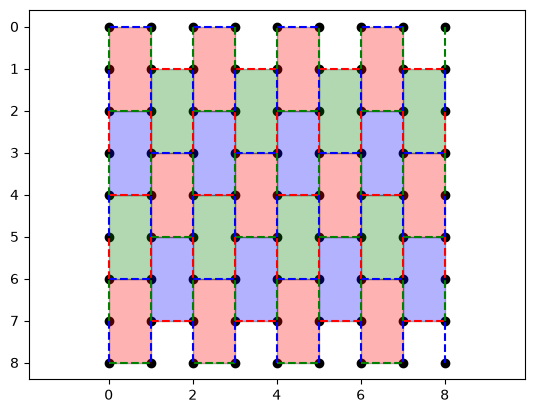

In [12]:
def colour_plaquette(y):
    # 3-colouring: guaranteed to differ from all 6 neighbors
    index = int(y%3)
    return ['red', 'green', 'blue'][index]

def colour_edge(x1, y1, x2, y2):
    # 3-colouring: guaranteed to differ from all 6 neighbors
    rgb = ['red', 'green', 'blue']
    if y1 == y2:
        return rgb[int((y2 - 1) % 3)]
    else:
        return rgb[int( (y1 + 1) % 3 )]

RGB = ['#e74c3c', '#2ecc71', '#3498db']

nx = 9
ny = 9
coords = np.array([(x, y) for y in range(ny) for x in range(nx)])
vertices = np.array([Vertex(i, z) for i, z in enumerate(coords)])

# preserving order is important here
edges = []
edge_count = 0
for i, z in enumerate(coords):
    
    x, y = z

    if y != 0: # vertical edges
        v0 = vertices[i-nx]
        v1 = vertices[i]

        x0, y0 = v0.pos
        x1, y1 = v1.pos

        colour = colour_edge(x0, y0, x1, y1)
        edge = Edge(edge_count, v0=v0, v1=v1, colour=colour)
        edges.append(edge)
        edge_count +=1
    
    if (x + y) % 2 == 0 and x != nx-1: # horizontal edges
        v0 = vertices[i]
        v1 = vertices[i+1]

        x0, y0 = v0.pos
        x1, y1 = v1.pos

        colour = colour_edge(x0, y0, x1, y1)
        edge = Edge(edge_count, v0=v0, v1=v1, colour=colour)
        edges.append(edge)
        edge_count += 1

plaquettes = []
plaquette_count = 0

for i, z in enumerate(coords):

    x, y = z

    # top-left vertex of a plaquette
    if (x + y) % 2 == 0 and x < nx - 1 and y < ny - 2:

        # vertices around plaquette, clockwise
        v0 = vertices[i]
        v1 = vertices[i + 1]
        v2 = vertices[i + nx]
        v3 = vertices[i + nx + 1]
        v4 = vertices[i + 2*nx]
        v5 = vertices[i + 2*nx + 1]

        plaquette = Plaquette(
            plaquette_count,
            vertices=[v0, v1, v2, v3, v4, v5],
            colour=colour_plaquette(y)
        )

        plaquettes.append(plaquette)
        plaquette_count += 1


plt.scatter(coords[..., 0], coords[..., 1], c='black')
for e in edges:
    e_coords = np.array(e.get_coordinates())
    plt.plot(e_coords[..., 0], e_coords[..., 1], "--", c=e.colour)

for p in plaquettes:
    p_coords = np.array(list(p.get_coordinates(ordered=True)))

    plt.fill(
        p_coords[..., 0],
        p_coords[..., 1],
        alpha=0.3,
        facecolor=p.colour,
        edgecolor="black"
    )

plt.axis('equal') 
plt.gca().yaxis.set_inverted(True)
plt.show()

We can now interact directly with the Surface class

In [7]:
from honeycomb import Surface

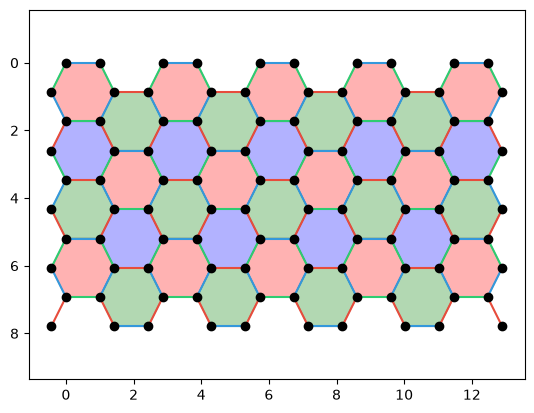

In [8]:
s = Surface(10, 10)
s.plot_surface(coordinates='hex')

And we will begin implementing some helper methods to let us interact with the stim circuit

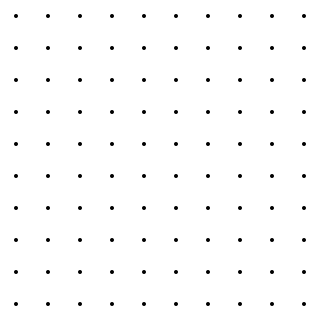

In [9]:
c = stim.Circuit(s.initialise_qubits())
c.diagram("detslice-svg")

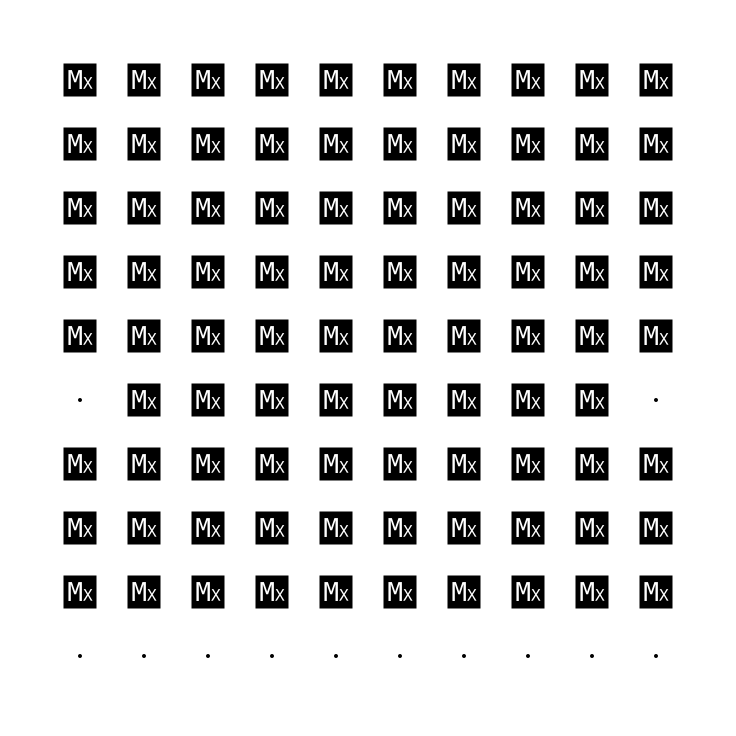

In [10]:
string = s.initialise_qubits(coordinates="square")
string += s.measure_edges('green', 'X')

c = stim.Circuit(string)
c.diagram("detslice-with-ops-svg")

This is my main method of debugging: just printing shit out and reading through it.

In [11]:
print(string)

QUBIT_COORDS(0,0) 0
QUBIT_COORDS(1,0) 1
QUBIT_COORDS(2,0) 2
QUBIT_COORDS(3,0) 3
QUBIT_COORDS(4,0) 4
QUBIT_COORDS(5,0) 5
QUBIT_COORDS(6,0) 6
QUBIT_COORDS(7,0) 7
QUBIT_COORDS(8,0) 8
QUBIT_COORDS(9,0) 9
QUBIT_COORDS(0,1) 10
QUBIT_COORDS(1,1) 11
QUBIT_COORDS(2,1) 12
QUBIT_COORDS(3,1) 13
QUBIT_COORDS(4,1) 14
QUBIT_COORDS(5,1) 15
QUBIT_COORDS(6,1) 16
QUBIT_COORDS(7,1) 17
QUBIT_COORDS(8,1) 18
QUBIT_COORDS(9,1) 19
QUBIT_COORDS(0,2) 20
QUBIT_COORDS(1,2) 21
QUBIT_COORDS(2,2) 22
QUBIT_COORDS(3,2) 23
QUBIT_COORDS(4,2) 24
QUBIT_COORDS(5,2) 25
QUBIT_COORDS(6,2) 26
QUBIT_COORDS(7,2) 27
QUBIT_COORDS(8,2) 28
QUBIT_COORDS(9,2) 29
QUBIT_COORDS(0,3) 30
QUBIT_COORDS(1,3) 31
QUBIT_COORDS(2,3) 32
QUBIT_COORDS(3,3) 33
QUBIT_COORDS(4,3) 34
QUBIT_COORDS(5,3) 35
QUBIT_COORDS(6,3) 36
QUBIT_COORDS(7,3) 37
QUBIT_COORDS(8,3) 38
QUBIT_COORDS(9,3) 39
QUBIT_COORDS(0,4) 40
QUBIT_COORDS(1,4) 41
QUBIT_COORDS(2,4) 42
QUBIT_COORDS(3,4) 43
QUBIT_COORDS(4,4) 44
QUBIT_COORDS(5,4) 45
QUBIT_COORDS(6,4) 46
QUBIT_COORDS(7,4) 47
QU